# 01 - Branch and X: Branch and Bound

**Objetivo del notebook.** Entender la familia *Branch and X* a partir de su caso central: **Branch and Bound**. Aunque Branch and Bound es un metodo exacto y no una metaheuristica pura, se incluye porque sirve como contraste: busca certificar optimalidad, mientras que las metaheuristicas normalmente buscan buenas soluciones sin garantia exacta.


## 1. Idea general

Branch and Bound explora un arbol de decisiones. Cada nodo representa un subproblema: algunas decisiones ya estan fijadas y otras siguen libres.

- **Branch**: divide el problema en subproblemas mas pequenos.
- **Bound**: calcula una cota optimista de lo mejor que podria lograrse desde ese nodo.
- **Prune**: descarta un nodo si su cota no puede mejorar la mejor solucion encontrada.

En problemas de maximizacion, una cota superior menor o igual que la mejor solucion actual permite podar. En minimizacion se usa la idea simetrica con cotas inferiores.


## 2. Codigo base generico

El siguiente motor es generico para problemas de **maximizacion**. Recibe funciones especificas del problema: como ramificar, como calcular la cota, como reconocer una solucion completa y como medir su valor.


In [1]:
def branch_and_bound(root, branch, bound, is_solution, value):
    """Motor generico de Branch and Bound para maximizacion."""
    best_solution = None
    best_value = -float("inf")
    stats = {"explorados": 0, "podados": 0, "soluciones": 0}
    stack = [root]

    while stack:
        node = stack.pop()
        stats["explorados"] += 1

        optimistic = bound(node)
        if optimistic <= best_value:
            stats["podados"] += 1
            continue

        if is_solution(node):
            stats["soluciones"] += 1
            candidate_value = value(node)
            if candidate_value > best_value:
                best_value = candidate_value
                best_solution = node
            continue

        children = branch(node)
        # Los nodos con mejor cota se dejan al final para salir primero del stack.
        children = sorted(children, key=bound)
        stack.extend(children)

    return best_solution, best_value, stats


## 3. Ejemplo: mochila 0/1

Tenemos objetos con valor y peso. La decision es binaria: tomar o no tomar cada objeto. El objetivo es maximizar el valor total sin superar la capacidad de la mochila.

El ejemplo usa una cota superior por **relajacion fraccionaria**: despues de fijar algunas decisiones, permite llenar el espacio restante con fracciones de objetos. Esa solucion no necesariamente es factible para la mochila 0/1, pero entrega una cota optimista util para podar.


In [2]:
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


def make_tsp_instance(n=20, seed=42):
    """Crea una instancia reproducible de ciudades en el plano [0, 1] x [0, 1]."""
    rng = np.random.default_rng(seed)
    return rng.random((n, 2))


def distance_matrix(coords):
    """Calcula la matriz de distancias euclidianas entre ciudades."""
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def tour_length(tour, D):
    """Costo total de una ruta cerrada que vuelve al punto inicial."""
    return float(sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))))


def plot_tour(coords, tour, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = list(tour) + [tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.8)
    for idx, (x, y) in enumerate(coords):
        ax.text(x + 0.008, y + 0.008, str(idx), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_convergence(history, title, ylabel="Mejor costo", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Iteracion")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax


In [3]:
rng = np.random.default_rng(7)
values = rng.integers(12, 80, size=16)
weights = rng.integers(5, 35, size=16)
capacity = int(weights.sum() * 0.42)

order = sorted(range(len(values)), key=lambda i: values[i] / weights[i], reverse=True)
values_ord = values[order]
weights_ord = weights[order]


def make_node(index=0, total_value=0, total_weight=0, chosen=None):
    return {
        "index": index,
        "value": int(total_value),
        "weight": int(total_weight),
        "chosen": tuple(chosen or ()),
    }


def kp_bound(node):
    if node["weight"] > capacity:
        return -float("inf")
    remaining = capacity - node["weight"]
    estimate = float(node["value"])
    i = node["index"]
    while i < len(values_ord) and weights_ord[i] <= remaining:
        remaining -= weights_ord[i]
        estimate += values_ord[i]
        i += 1
    if i < len(values_ord):
        estimate += values_ord[i] * (remaining / weights_ord[i])
    return estimate


def kp_branch(node):
    i = node["index"]
    if i >= len(values_ord):
        return []
    include = make_node(
        i + 1,
        node["value"] + values_ord[i],
        node["weight"] + weights_ord[i],
        node["chosen"] + (order[i],),
    )
    exclude = make_node(i + 1, node["value"], node["weight"], node["chosen"])
    return [include, exclude]


def kp_is_solution(node):
    return node["index"] == len(values_ord)


def kp_value(node):
    return node["value"] if node["weight"] <= capacity else -float("inf")

best_node, best_value, stats = branch_and_bound(
    make_node(), kp_branch, kp_bound, kp_is_solution, kp_value
)
chosen = sorted(best_node["chosen"])

print(f"Capacidad: {capacity}")
print(f"Mejor valor encontrado: {best_value}")
print(f"Peso usado: {best_node['weight']}")
print(f"Objetos elegidos: {chosen}")
print(f"Nodos explorados: {stats['explorados']} | podados: {stats['podados']} | soluciones completas: {stats['soluciones']}")


Capacidad: 128
Mejor valor encontrado: 551
Peso usado: 122
Objetos elegidos: [0, 2, 3, 5, 6, 11, 12, 15]
Nodos explorados: 33 | podados: 16 | soluciones completas: 1


### Explicacion general del codigo ejemplo

1. Los objetos se ordenan por razon valor/peso para que la cota fraccionaria sea fuerte.
2. Cada nodo guarda el indice del proximo objeto, el valor acumulado, el peso acumulado y los objetos elegidos.
3. La funcion `kp_bound` estima el mejor valor posible desde un nodo si se permitieran fracciones.
4. La funcion `kp_branch` crea dos ramas: incluir el objeto o excluirlo.
5. El motor generico recorre el arbol y poda las ramas que ya no pueden superar la mejor solucion.


<notebook-cell>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


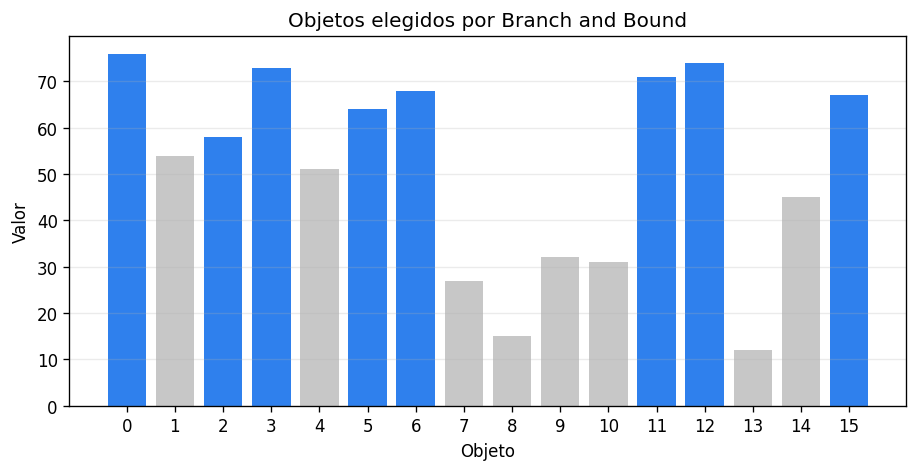

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(values))
colors = ["#2f80ed" if i in chosen else "#c7c7c7" for i in range(len(values))]
ax.bar(x, values, color=colors, label="Valor")
ax.set_title("Objetos elegidos por Branch and Bound")
ax.set_xlabel("Objeto")
ax.set_ylabel("Valor")
ax.set_xticks(x)
ax.grid(axis="y", alpha=0.25)
plt.show()


## 4. Parametros, ventajas y limites

Branch and Bound puede demostrar optimalidad, pero su peor caso sigue siendo exponencial. La calidad de la cota es clave: una cota fuerte reduce el arbol; una cota debil se parece a fuerza bruta. En la familia *Branch and X*, la X puede ser **Cut** (cortes), **Price** (generacion de columnas) u otras tecnicas que fortalecen la relajacion usada para acotar.
